# Research Analyst Network

In [1]:
!pip install langgraph langsmith langchain_classic langchain_community langchain_groq langchain_core pydantic chromadb langchain-tavily langchain_huggingface youtube_search wikipedia httpx langchain_google_genai streamlit transformers yfinance langchain_openrouter typing-extensions langchain-text-splitters langchain-experimental

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 106.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 86.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 111.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.2/211.2 kB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 132.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 102.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 704.7/704.7 kB 43.1 MB/s eta 0:00:00
   ━━━━

In [2]:
import os
from google.colab import userdata
os.environ['GROQ_API_KEY'] = userdata.get('GROQ_API_KEY')
os.environ['OPENROUTER_API_KEY'] = userdata.get('OPENROUTER_API_KEY').strip()

os.environ["TAVILY_API_KEY"]= userdata.get("TAVILY_API_KEY")
os.environ["SERPER_API_KEY"]= userdata.get("SERPER_API_KEY")
os.environ["LANGCHAIN_API_KEY"] = userdata.get("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"

In [3]:
# from langchain_groq import ChatGroq
# llm=ChatGroq(model_name="llama-3.3-70b-versatile")

from langchain_openrouter import ChatOpenRouter

llm = ChatOpenRouter(
    model="openrouter/free",
)

In [4]:
from typing_extensions import Literal
from langchain_core.tools import tool
from langgraph.graph import MessagesState, StateGraph, START, END
from langgraph.types import Command
from IPython.display import Image, display
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.prebuilt import create_react_agent
from typing import Annotated
from langchain_experimental.utilities import PythonREPL
from langchain_community.tools import DuckDuckGoSearchRun

/tmp/ipykernel_1288/351181059.py:9: DeprecationWarning: `langchain-experimental` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-experimental/issues/87 for details.
  from langchain_experimental.utilities import PythonREPL
/tmp/ipykernel_1288/351181059.py:10: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun


In [5]:
llm.invoke("hi")

AIMessage(content='User Safety: safe', additional_kwargs={'reasoning_content': '\nWe need to classify user input: "hi". It\'s safe. No assistant response present (the conversation only has user, no assistant). So we output:\n\nUser Safety: safe\nResponse Safety: (omit) as no assistant response present.\n\nThus output exactly:\n\nUser Safety: safe\n\nWe should not include Response Safety line.\n\n\n', 'reasoning_details': [{'type': 'reasoning.text', 'format': 'unknown', 'index': 0, 'text': '\nWe need to classify user input: "hi". It\'s safe. No assistant response present (the conversation only has user, no assistant). So we output:\n\nUser Safety: safe\nResponse Safety: (omit) as no assistant response present.\n\nThus output exactly:\n\nUser Safety: safe\n\nWe should not include Response Safety line.\n\n\n'}]}, response_metadata={'model_name': 'nvidia/nemotron-3.5-content-safety-20260604:free', 'id': 'gen-1782164509-4c2x3E5i3zdFiGYgJM0x', 'created': 1782164509, 'object': 'chat.completio

In [7]:
!pip install -U ddgs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 19.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 147.8 MB/s eta 0:00:00


In [8]:
search_tool = DuckDuckGoSearchRun()

In [9]:
search_tool.invoke("What is the GDP of China?")

"Gross domestic product (GDP) is the market value of all final goods and services from a nation in a given year. [2] Countries are sorted by nominal GDP estimates from financial and statistical institutions, which are calculated at market or government official exchange rates. It is one of the five permanent members of the UN Security Council and a member of many multilateral organizations. China is the world's largest manufacturer and makes up about one-fifth of the global economy. It is the second largest economy on Earth. International organizations rank China poorly in measures of democracy and human rights. Explore China GDP from 1960 to 2025 with annual growth rates and historical trends. Official NBS data. Free API & CSV download. China contributes 16.6% of the entire world's GDP. China's share of the world economy increased from 1.57 percent in 1987 to an all-time high of 18.5 percent in 2021. The Chinese economy crossed the $1 trillion mark in 1998 and the $2 trillion mark in 

In [10]:
repl = PythonREPL()

In [11]:
code = """
x = 5
y = x + 5
print(y)
"""

In [12]:
repl.run(code)

'10\n'

In [13]:
@tool
def pythonprogramming_repl_tool(
    code: Annotated[str, "The python programming code to execute to gnerate your chart."],):

  """Use this to execute python programming code. If you want to see the output of a value,
      you should print it out with `print(...)`. This is visible to the user."""

  try:
    result = repl.run(code)

  except Exception as e:
    return f"Failed to execute. Error: {repr(e)}"

  result_str = f"Successfully executed:\n\`\`\`python programming\n{code}\n\`\`\`\nStdout: {result}"
  return (
      result_str + "\n\nIf you have completed all tasks, respond with FINAL ANSWER."
  )



<>:14: SyntaxWarning: invalid escape sequence '\`'
<>:14: SyntaxWarning: invalid escape sequence '\`'
<>:14: SyntaxWarning: invalid escape sequence '\`'
<>:14: SyntaxWarning: invalid escape sequence '\`'
/tmp/ipykernel_1288/3350486729.py:14: SyntaxWarning: invalid escape sequence '\`'
  result_str = f"Successfully executed:\n\`\`\`python programming\n{code}\n\`\`\`\nStdout: {result}"
/tmp/ipykernel_1288/3350486729.py:14: SyntaxWarning: invalid escape sequence '\`'
  result_str = f"Successfully executed:\n\`\`\`python programming\n{code}\n\`\`\`\nStdout: {result}"


In [14]:
def make_system_prompt(instruction: str) -> str:
  return  (
        "You are a helpful AI assistant, collaborating with other assistants."
        " Use the provided tools to progress towards answering the question."
        " If you are unable to fully answer, that's OK, another assistant with different tools "
        " will help where you left off. Execute what you can to make progress."
        " If you or any of the other assistants have the final answer or deliverable,"
        " prefix your response with FINAL ANSWER so the team knows to stop."
        f"\n{instruction}"
    )

In [15]:
make_system_prompt(
    "You can only do research. You are working with a chart generator colleague."
)

"You are a helpful AI assistant, collaborating with other assistants. Use the provided tools to progress towards answering the question. If you are unable to fully answer, that's OK, another assistant with different tools  will help where you left off. Execute what you can to make progress. If you or any of the other assistants have the final answer or deliverable, prefix your response with FINAL ANSWER so the team knows to stop.\nYou can only do research. You are working with a chart generator colleague."

In [16]:
"You are a helpful AI assistant, collaborating with other assistants. Use the provided tools to progress towards answering the question. If you are unable to fully answer, that's OK, another assistant with different tools  will help where you left off. Execute what you can to make progress. If you or any of the other assistants have the final answer or deliverable, prefix your response with FINAL ANSWER so the team knows to stop.\nYou can only do research. You are working with a chart generator colleague."

"You are a helpful AI assistant, collaborating with other assistants. Use the provided tools to progress towards answering the question. If you are unable to fully answer, that's OK, another assistant with different tools  will help where you left off. Execute what you can to make progress. If you or any of the other assistants have the final answer or deliverable, prefix your response with FINAL ANSWER so the team knows to stop.\nYou can only do research. You are working with a chart generator colleague."

In [17]:
def get_next_code(last_message: BaseMessage, goto:str):
  if "FINAL ANSWER" in last_message.content:
    # Any agent decided the work is done
    return END
  return goto


In [18]:
research_agent = create_react_agent(
    llm,
    tools=[search_tool],
    prompt = make_system_prompt(
        "You can only do research. You are working with a chart generator colleague."
    ),
)

/tmp/ipykernel_1288/739040456.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  research_agent = create_react_agent(


In [19]:
chart_agent = create_react_agent(
    llm,
    tools=[pythonprogramming_repl_tool],
    prompt = make_system_prompt(
        "You can only generate charts. You are working with a researcher colleague."
    ),
)

/tmp/ipykernel_1288/1961150677.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  chart_agent = create_react_agent(


In [20]:
state = {"message": ["hi", "hello"]}

In [21]:
state["message"][-1]

'hello'

In [25]:
from langgraph.graph import StateGraph, START, END



In [26]:
def research_node(state: MessagesState) -> Command[Literal["chart_generator", END]]:

  result = research_agent.invoke(state)

  goto = get_next_code(result["messages"][-1], "chart_generator")

  result["messages"][-1] = HumanMessage(content=result["messages"][-1].content, name="researcher")

  return Command(update={"messages": result["messages"]}, goto=goto)

In [27]:
def chart_node(state: MessagesState) -> Command[Literal["researcher", END]]:

  result = chart_agent.invoke(state)

  goto = get_next_code(result["messages"][-1], "researcher")

  result["messages"][-1] = HumanMessage(content=result["messages"][-1].content, name="chart_generator")

  return Command(update={"messages": result["messages"]}, goto=goto)

In [28]:
workflow = StateGraph(MessagesState)
workflow.add_node("researcher", research_node)
workflow.add_node("chart_generator", chart_node)

workflow.add_edge(START, "researcher")
app = workflow.compile()

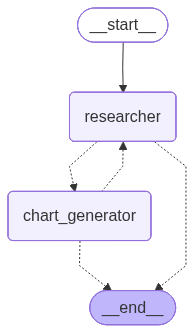

In [29]:
display(Image(app.get_graph().draw_mermaid_png()))

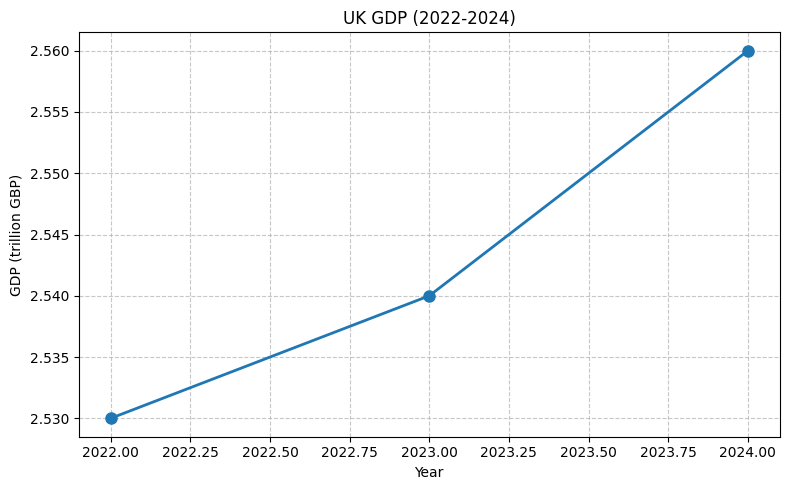

{'messages': [HumanMessage(content="get the UK's GDP over the past 3 years, then make a line chart of it.Once you make the chart, finish.", additional_kwargs={}, response_metadata={}, id='de98ea48-2b63-43c9-a0f9-f8a7a28f8e50'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'Need recent GDP data. Use DuckDuckGo search.', 'reasoning_details': [{'type': 'reasoning.text', 'format': 'unknown', 'index': 0, 'text': 'Need recent GDP data. Use DuckDuckGo search.'}]}, response_metadata={'model_name': 'openai/gpt-oss-20b:free', 'id': 'gen-1782164803-zN4w6Yo38NHk91fdNyt8', 'created': 1782164803, 'object': 'chat.completion', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'openrouter', 'cost': 0.0, 'cost_details': {'upstream_inference_completions_cost': 0.0, 'upstream_inference_prompt_cost': 0.0, 'upstream_inference_cost': 0.0}}, id='lc_run--019ef14c-cd44-7492-baf0-4bf110bd0833-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'UK GDP 2021 2022 202

In [30]:
app.invoke({"messages": [("user","get the UK's GDP over the past 3 years, then make a line chart of it.Once you make the chart, finish.")],})